DOWNLOAD DATASET

In [1]:
!mkdir -p VOCdevkit

!wget http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar -O VOCdevkit/VOCtrainval_11-May-2012.tar

!tar -xvf VOCdevkit/VOCtrainval_11-May-2012.tar -C VOCdevkit/

!ls VOCdevkit/VOCdevkit/VOC2012/


Streaming output truncated to the last 5000 lines.
VOCdevkit/VOC2012/SegmentationClass/2008_001876.png
VOCdevkit/VOC2012/SegmentationClass/2008_001882.png
VOCdevkit/VOC2012/SegmentationClass/2008_001885.png
VOCdevkit/VOC2012/SegmentationClass/2008_001895.png
VOCdevkit/VOC2012/SegmentationClass/2008_001896.png
VOCdevkit/VOC2012/SegmentationClass/2008_001926.png
VOCdevkit/VOC2012/SegmentationClass/2008_001966.png
VOCdevkit/VOC2012/SegmentationClass/2008_001971.png
VOCdevkit/VOC2012/SegmentationClass/2008_001992.png
VOCdevkit/VOC2012/SegmentationClass/2008_001997.png
VOCdevkit/VOC2012/SegmentationClass/2008_002032.png
VOCdevkit/VOC2012/SegmentationClass/2008_002043.png
VOCdevkit/VOC2012/SegmentationClass/2008_002064.png
VOCdevkit/VOC2012/SegmentationClass/2008_002066.png
VOCdevkit/VOC2012/SegmentationClass/2008_002067.png
VOCdevkit/VOC2012/SegmentationClass/2008_002073.png
VOCdevkit/VOC2012/SegmentationClass/2008_002079.png
VOCdevkit/VOC2012/SegmentationClass/2008_002080.png
VOCdevkit/VOC

In [2]:
import os
import xml.etree.ElementTree as ET
from PIL import Image, ImageFile
import torch
from torch.utils.data import Dataset, DataLoader

ImageFile.LOAD_TRUNCATED_IMAGES = True

VOC_CLASSES = {
    "person": 1,
    "car": 2,
    "dog": 3,
    "cat": 4,
    "bottle": 5
}

class VOCDataset(Dataset):
    def __init__(self, root, image_set="train", transforms=None):
        self.root = root
        self.transforms = transforms
        image_set_file = os.path.join(root, "ImageSets", "Main", f"{image_set}.txt")
        with open(image_set_file) as f:
            self.image_ids = [line.strip() for line in f]

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        try:
            image_id = self.image_ids[idx]
            img_path = os.path.join(self.root, "JPEGImages", f"{image_id}.jpg")
            ann_path = os.path.join(self.root, "Annotations", f"{image_id}.xml")

            try:
                image = Image.open(img_path).convert("RGB")
            except (OSError, IOError) as e:
                print(f"Warning: Skipping corrupted image {image_id}: {e}")
                return None

            boxes = []
            labels = []
            tree = ET.parse(ann_path)
            xml_root = tree.getroot()
            for obj in xml_root.findall("object"):
                name = obj.find("name").text.lower()
                if name not in VOC_CLASSES:
                    continue
                bbox = obj.find("bndbox")
                xmin = float(bbox.find("xmin").text)
                ymin = float(bbox.find("ymin").text)
                xmax = float(bbox.find("xmax").text)
                ymax = float(bbox.find("ymax").text)
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(VOC_CLASSES[name])

            if len(boxes) == 0:
                return None
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((labels.shape[0],), dtype=torch.int64)

            target = {
                "boxes": boxes,
                "labels": labels,
                "image_id": torch.tensor([idx]),
                "area": area,
                "iscrowd": iscrowd
            }

            if self.transforms:
                result = self.transforms(image, target)
                if result is None:
                    return None
                image, target = result

            if target["boxes"].numel() == 0:
                return None

            return image, target

        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            return None

In [3]:
!ls VOCdevkit/VOCdevkit/VOC2012


Annotations  ImageSets	JPEGImages  SegmentationClass  SegmentationObject


In [4]:
!ls VOCdevkit/VOCdevkit/VOC2012/ImageSets/Main/train.txt


VOCdevkit/VOCdevkit/VOC2012/ImageSets/Main/train.txt


In [5]:
dataset = VOCDataset(
    root="VOCdevkit/VOCdevkit/VOC2012",
    image_set="train"
)

print("Total images:", len(dataset))

image, target = dataset[0]

print("Image type:", type(image))
print("Boxes:", target["boxes"])
print("Labels:", target["labels"])


Total images: 5717
Image type: <class 'PIL.Image.Image'>
Boxes: tensor([[158.,  44., 289., 167.]])
Labels: tensor([1])


Data Augmentation

In [6]:
!pip install -q albumentations opencv-python --no-deps


In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_train_transforms():
    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.ShiftScaleRotate(
                shift_limit=0.0625, scale_limit=0.1, rotate_limit=10,
                border_mode=0, p=0.5
            ),
            A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
            ToTensorV2()
        ],
        bbox_params=A.BboxParams(
            format="pascal_voc",
            label_fields=["labels"],
            min_area=1, min_visibility=0.3
        )
    )

def get_val_transforms():
    return A.Compose(
        [
            A.Resize(512, 512),
            A.Normalize(mean=(0,0,0), std=(1,1,1), max_pixel_value=255.0),
            ToTensorV2()
        ],
        bbox_params=A.BboxParams(
            format="pascal_voc",
            label_fields=["labels"]
        )
    )


In [9]:
class AlbumentationsWrapper:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image, target):
        image_np = np.array(image)
        transformed = self.transform(
            image=image_np,
            bboxes=target["boxes"].numpy(),
            labels=target["labels"].numpy()
        )
        image = transformed["image"]
        boxes = torch.as_tensor(transformed["bboxes"], dtype=torch.float32)
        labels = torch.as_tensor(transformed["labels"], dtype=torch.int64)

        keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        boxes = boxes[keep]
        labels = labels[keep]
        if boxes.numel() == 0:
            return None

        target["boxes"] = boxes
        target["labels"] = labels

        target["area"] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        target["iscrowd"] = torch.zeros((labels.shape[0],), dtype=torch.int64)

        return image, target

In [10]:
train_dataset = VOCDataset(
    root="VOCdevkit/VOCdevkit/VOC2012",
    image_set="train",
    transforms=AlbumentationsWrapper(get_train_transforms())
)
val_dataset = VOCDataset(
    root="VOCdevkit/VOCdevkit/VOC2012",
    image_set="val",
    transforms=AlbumentationsWrapper(get_val_transforms())
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [11]:
img, target = train_dataset[0]
print(img.dtype, img.min(), img.max(), target["boxes"].shape)

torch.float32 tensor(0.) tensor(1.) torch.Size([1, 4])


Visualize Augmented Samples

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

INV_VOC_CLASSES = {v: k for k, v in VOC_CLASSES.items()}

def visualize_sample(image, target):

    img = image.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)
    ax.axis("off")

    boxes = target["boxes"]
    labels = target["labels"]

    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box.tolist()
        width = xmax - xmin
        height = ymax - ymin

        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        class_name = INV_VOC_CLASSES[label.item()]
        ax.text(
            xmin,
            ymin - 5,
            class_name,
            color="yellow",
            fontsize=12,
            bbox=dict(facecolor="black", alpha=0.5)
        )

    plt.show()


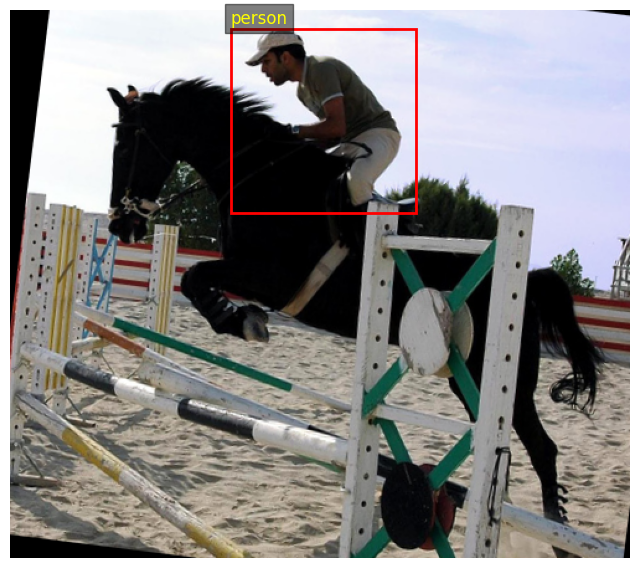

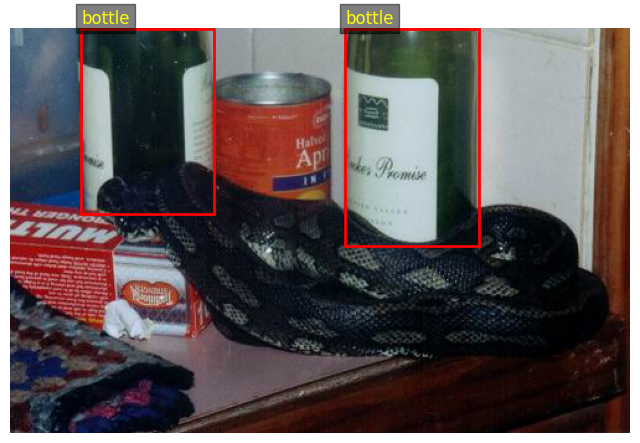

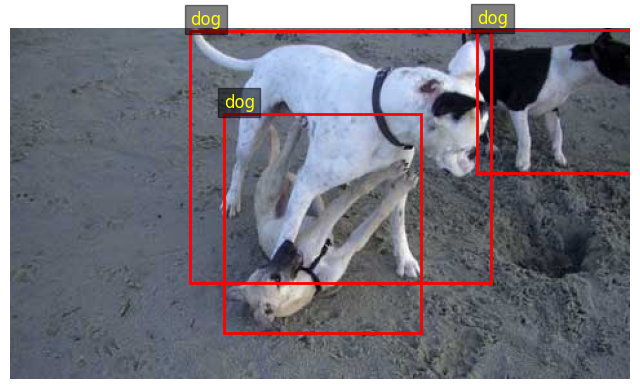

In [13]:
for i in range(3):
    img, target = train_dataset[i]
    visualize_sample(img, target)


In [14]:
def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=4, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=2, collate_fn=collate_fn
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Model Initialization

In [15]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

In [16]:
backbone = resnet_fpn_backbone(
    "resnet50",
    weights="IMAGENET1K_V1"
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 84.3MB/s]


In [17]:
num_classes = 6

model = FasterRCNN(backbone=backbone, num_classes=num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [18]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

In [19]:
from tqdm import tqdm
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0.0
    valid_batches = 0

    for batch in tqdm(data_loader, desc=f"Epoch {epoch}"):
        if batch is None:
            continue
        images, targets = batch
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if torch.isnan(losses):
            print(f"NaN loss at epoch {epoch}, skipping batch")
            continue

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        valid_batches += 1

    if valid_batches > 0:
        avg_loss = total_loss / valid_batches
        print(f"Epoch {epoch} | Avg Loss: {avg_loss:.4f}")
        return avg_loss

    else:
        print(f"Epoch {epoch} | No valid batches processed!")
        return None



In [20]:
@torch.no_grad()
def evaluate_loss(model, data_loader, device, epoch):
    model.train()

    total_loss = 0.0
    valid_batches = 0

    for batch in tqdm(data_loader, desc=f"Val Epoch {epoch}"):
        if batch is None:
            continue

        images, targets = batch
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if torch.isnan(losses):
            print(f"NaN val loss at epoch {epoch}, skipping batch")
            continue

        total_loss += losses.item()
        valid_batches += 1

    model.eval()

    if valid_batches > 0:
        return total_loss / valid_batches
    else:
        return None


In [ ]:
train_losses = []
val_losses = []

num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model, optimizer, train_loader, device, epoch
    )

    val_loss = evaluate_loss(
        model, val_loader, device, epoch
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    lr_scheduler.step()

    print(
        f"Epoch {epoch}: "
        f"Train={train_loss:.4f} | Val={val_loss:.4f}"
    )


Epoch 0: 100%|██████████| 1430/1430 [08:43<00:00,  2.73it/s]


Epoch 0 | Avg Loss: 0.4223


Val Epoch 0: 100%|██████████| 1456/1456 [02:40<00:00,  9.10it/s]


Epoch 0: Train=0.4223 | Val=0.3747


Epoch 1: 100%|██████████| 1430/1430 [08:43<00:00,  2.73it/s]


...

Epoch 3: Train=0.3305 | Val=0.3382


Epoch 4: 100%|██████████| 1430/1430 [08:52<00:00,  2.69it/s]


Epoch 4 | Avg Loss: 0.3276


Val Epoch 4: 100%|██████████| 1456/1456 [02:40<00:00,  9.08it/s]

Epoch 4: Train=0.3276 | Val=0.3383


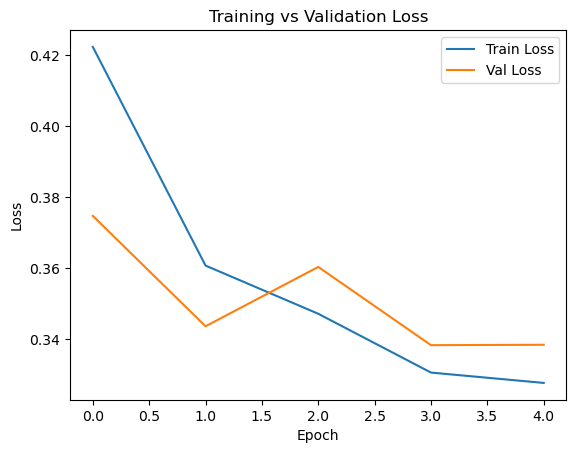

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [ ]:
torch.save(model.state_dict(), "fasterrcnn_weights.pth")


In [22]:
model.load_state_dict(
    torch.load("fasterrcnn_weights.pth", map_location=device)
)

model.to(device)
model.eval()


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [23]:
@torch.no_grad()
def inference(model, images, device):
    model.eval()
    images = [img.to(device) for img in images]
    outputs = model(images)
    return outputs


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

INV_VOC_CLASSES = {v: k for k, v in VOC_CLASSES.items()}

def visualize_predictions(image, output, score_thresh=0.5):

    img = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)
    ax.axis("off")

    boxes = output["boxes"].cpu()
    labels = output["labels"].cpu()
    scores = output["scores"].cpu()

    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue

        xmin, ymin, xmax, ymax = box.tolist()
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)

        class_name = INV_VOC_CLASSES[label.item()]
        ax.text(
            xmin,
            ymin - 5,
            f"{class_name}: {score:.2f}",
            color="yellow",
            fontsize=12,
            bbox=dict(facecolor="black", alpha=0.5)
        )

    plt.show()


In [25]:
!pip install torchmetrics
!pip install pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 17.7 MB/s eta 0:00:00


In [26]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch

@torch.no_grad()
def evaluate_map(model, data_loader, device):
    model.eval()

    metric = MeanAveragePrecision(iou_type="bbox")

    for batch in data_loader:
        if batch is None:
            continue

        images, targets = batch
        images = [img.to(device) for img in images]

        outputs = model(images)

        outputs = [
            {k: v.cpu() for k, v in out.items()}
            for out in outputs
        ]

        targets = [
            {k: v.cpu() for k, v in tgt.items()}
            for tgt in targets
        ]

        metric.update(outputs, targets)

    return metric.compute()


In [ ]:
map_results = evaluate_map(model, val_loader, device)

print("mAP@0.5:", map_results["map_50"].item())
print("mAP (0.5:0.95):", map_results["map"].item())


mAP@0.5: 0.5527912974357605
mAP (0.5:0.95): 0.2442028671503067


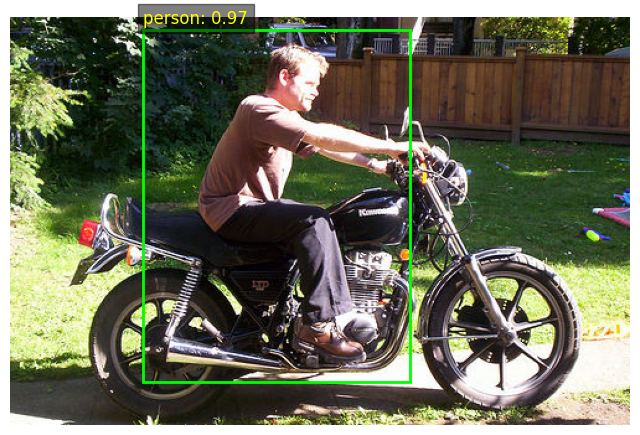

In [32]:
import torchvision.transforms.functional as F

image_path = "5.jpg"

image = Image.open(image_path).convert("RGB")
image_tensor = F.to_tensor(image)

model.eval()

with torch.no_grad():
    output = inference(model, [image_tensor], device)[0]

visualize_predictions(image_tensor, output, score_thresh=0.8)